In [ ]:
from requests import Request, Session
from requests.exceptions import ConnectionError, Timeout, TooManyRedirects
import json

url = 'https://pro-api.coinmarketcap.com/v1/cryptocurrency/listings/latest' 
#Original Sandbox Environment: 'https://sandbox-api.coinmarketcap.com/v1/cryptocurrency/listings/latest'
parameters = {
  'start':'1',
  'limit':'15',
  'convert':'USD'
}
headers = {
  'Accepts': 'application/json',
  'X-CMC_PRO_API_KEY': '0ad53085-1cb2-4eb8-ad9e-3ffbd7e56509',
}

session = Session()
session.headers.update(headers)

try:
  response = session.get(url, params=parameters)
  data = json.loads(response.text)
  #print(data)
except (ConnectionError, Timeout, TooManyRedirects) as e:
  print(e)

#NOTE:
# I had to go in and put "jupyter notebook --NotebookApp.iopub_data_rate_limit=1e10"
# Into the Anaconda Prompt to change this to allow to pull data

# If that didn't work try using the local host URL as shown in the video

In [ ]:
type(data)

In [ ]:
import pandas as pd


#This allows you to see all the columns, not just like 15
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [ ]:
#This normalizes the data and makes it all pretty in a dataframe

df = pd.json_normalize(data['data'])
df['timestamp'] = pd.to_datetime('now')
df

In [33]:
def api_runner():
    global df
    url = 'https://pro-api.coinmarketcap.com/v1/cryptocurrency/listings/latest' 
    #Original Sandbox Environment: 'https://sandbox-api.coinmarketcap.com/v1/cryptocurrency/listings/latest'
    parameters = {
      'start':'1',
      'limit':'15',
      'convert':'USD'
    }
    headers = {
      'Accepts': 'application/json',
      'X-CMC_PRO_API_KEY': '0ad53085-1cb2-4eb8-ad9e-3ffbd7e56509',
    }

    session = Session()
    session.headers.update(headers)

    try:
      response = session.get(url, params=parameters)
      data = json.loads(response.text)
      #print(data)
    except (ConnectionError, Timeout, TooManyRedirects) as e:
      print(e)
    
    # Use this if you just want to keep it in a dataframe
    df2 = pd.json_normalize(data['data'])
    df2['Timestamp'] = pd.to_datetime('now')
    df = pd.concat([df, df2], ignore_index=True)

In [34]:
import os 
from time import time
from time import sleep

for i in range(333):
    api_runner()
    print('API Runner Completed')
    sleep(60) #sleep for 1 minute
exit()

API Runner Completed
API Runner Completed
API Runner Completed
API Runner Completed
API Runner Completed


KeyboardInterrupt: 

In [35]:
df

,id,name,symbol,slug,num_market_pairs,date_added,tags,max_supply,circulating_supply,total_supply,infinite_supply,platform,cmc_rank,self_reported_circulating_supply,self_reported_market_cap,tvl_ratio,last_updated,quote.USD.price,quote.USD.volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.name,platform.symbol,platform.slug,platform.token_address,timestamp,Timestamp
0,1,Bitcoin,BTC,bitcoin,12473,2010-07-13T00:00:00.000Z,"[mineable, pow, sha-256, store-of-value, state...",2.100000e+07,1.994854e+07,1.994854e+07,False,NaN,1,NaN,NaN,None,2025-11-14T16:49:00.000Z,96957.077941,1.285200e+11,67.5619,-0.232233,-3.878536,-4.208042,-12.478391,-15.604695,-17.737676,1.934152e+12,58.8083,2.036099e+12,None,2025-11-14T16:49:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-11-14 22:22:30.358940,NaT
1,1027,Ethereum,ETH,ethereum,11147,2015-08-07T00:00:00.000Z,"[pos, smart-contracts, ethereum-ecosystem, coi...",NaN,1.206964e+08,1.206964e+08,True,NaN,2,NaN,NaN,None,2025-11-14T16:49:00.000Z,3230.594171,5.585989e+10,35.8256,0.149031,-3.458838,-2.502516,-19.019088,-28.285707,-26.779835,3.899209e+11,11.8556,3.899209e+11,None,2025-11-14T16:49:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-11-14 22:22:30.358940,NaT
2,825,Tether USDt,USDT,tether,158344,2015-02-25T00:00:00.000Z,"[stablecoin, asset-backed-stablecoin, usd-stab...",NaN,1.840651e+11,1.869128e+11,True,NaN,3,NaN,NaN,None,2025-11-14T16:49:00.000Z,0.999554,2.051311e+11,52.7080,-0.038088,-0.020478,0.024265,-0.099204,-0.073561,-0.130962,1.839829e+11,5.5940,1.868294e+11,None,2025-11-14T16:49:00.000Z,1027.0,Ethereum,ETH,ethereum,0xdac17f958d2ee523a2206206994597c13d831ec7,2025-11-14 22:22:30.358940,NaT
3,52,XRP,XRP,xrp,1759,2013-08-04T00:00:00.000Z,"[medium-of-exchange, enterprise-solutions, xrp...",1.000000e+11,6.010720e+10,9.998577e+10,False,NaN,4,NaN,NaN,None,2025-11-14T16:49:00.000Z,2.325322,8.293507e+09,32.7280,0.119210,-3.702153,3.030151,-4.887154,-23.010815,-25.110477,1.397686e+11,4.2497,2.325322e+11,None,2025-11-14T16:49:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-11-14 22:22:30.358940,NaT
4,1839,BNB,BNB,bnb,2964,2017-07-25T00:00:00.000Z,"[marketplace, centralized-exchange, payments, ...",1.377371e+08,1.377371e+08,1.377371e+08,False,NaN,5,NaN,NaN,None,2025-11-14T16:49:00.000Z,930.709435,4.368651e+09,81.8971,0.236626,-2.123463,-1.911989,-21.164001,1.318847,11.568229,1.281932e+11,3.8977,1.281932e+11,None,2025-11-14T16:49:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-11-14 22:22:30.358940,NaT
5,5426,Solana,SOL,solana,1050,2020-04-10T00:00:00.000Z,"[pos, platform, solana-ecosystem, cms-holdings...",NaN,5.540290e+08,6.139614e+08,True,NaN,6,5.252369e+08,7.522854e+10,None,2025-11-14T16:49:00.000Z,143.227826,9.888352e+09,77.0168,-0.143642,-5.324480,-8.791855,-27.590197,-38.489768,-23.938395,7.935236e+10,2.4127,8.793636e+10,None,2025-11-14T16:49:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-11-14 22:22:30.358940,NaT
6,3408,USDC,USDC,usd-coin,34521,2018-10-08T00:00:00.000Z,"[medium-of-exchange, stablecoin, asset-backed-...",NaN,7.524095e+10,7.524095e+10,False,NaN,7,6.090122e+10,6.090398e+10,None,2025-11-14T16:49:00.000Z,1.000045,2.574273e+10,61.9408,-0.044346,0.010799,0.018234,0.021159,0.012243,0.007479,7.524436e+10,2.2878,7.524436e+10,None,2025-11-14T16:49:00.000Z,1027.0,Ethereum,ETH,ethereum,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,2025-11-14 22:22:30.358940,NaT
7,1958,TRON,TRX,tron,1259,2017-09-13T00:00:00.000Z,"[media, payments, tron-ecosystem, layer-1, dwf...",NaN,9.466873e+10,9.466868e+10,True,NaN,8,9.466789e+10,2.817348e+10,None,2025-11-14T16:49:00.000Z,0.297603,1.323309e+09,78.3418,0.530024,0.297675,3.098959,-5.357910,-13.295949,-14.098625,2.817373e+10,0.8566,2.817372e+10,None,2025-11-14T16:49:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-11-14 22:22:30.358940,NaT
8,74,Dogec

In [37]:
# One thing I noticed was the scientific notation. I like it, but I want to be able to see the numbers in this case

pd.set_option('display.float_format', lambda x: '%.5f' % x)

In [38]:
df

,id,name,symbol,slug,num_market_pairs,date_added,tags,max_supply,circulating_supply,total_supply,infinite_supply,platform,cmc_rank,self_reported_circulating_supply,self_reported_market_cap,tvl_ratio,last_updated,quote.USD.price,quote.USD.volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.name,platform.symbol,platform.slug,platform.token_address,timestamp,Timestamp
0,1,Bitcoin,BTC,bitcoin,12473,2010-07-13T00:00:00.000Z,"[mineable, pow, sha-256, store-of-value, state...",21000000.00000,19948537.00000,19948537.00000,False,NaN,1,NaN,NaN,None,2025-11-14T16:49:00.000Z,96957.07794,128520030673.77721,67.56190,-0.23223,-3.87854,-4.20804,-12.47839,-15.60470,-17.73768,1934151856722.75317,58.80830,2036098636766.09009,None,2025-11-14T16:49:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-11-14 22:22:30.358940,NaT
1,1027,Ethereum,ETH,ethereum,11147,2015-08-07T00:00:00.000Z,"[pos, smart-contracts, ethereum-ecosystem, coi...",NaN,120696353.18379,120696353.18379,True,NaN,2,NaN,NaN,None,2025-11-14T16:49:00.000Z,3230.59417,55859886871.15456,35.82560,0.14903,-3.45884,-2.50252,-19.01909,-28.28571,-26.77984,389920935061.24268,11.85560,389920935061.23999,None,2025-11-14T16:49:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-11-14 22:22:30.358940,NaT
2,825,Tether USDt,USDT,tether,158344,2015-02-25T00:00:00.000Z,"[stablecoin, asset-backed-stablecoin, usd-stab...",NaN,184065108793.92068,186912846198.86810,True,NaN,3,NaN,NaN,None,2025-11-14T16:49:00.000Z,0.99955,205131139135.08569,52.70800,-0.03809,-0.02048,0.02426,-0.09920,-0.07356,-0.13096,183982947158.98727,5.59400,186829413411.76999,None,2025-11-14T16:49:00.000Z,1027.00000,Ethereum,ETH,ethereum,0xdac17f958d2ee523a2206206994597c13d831ec7,2025-11-14 22:22:30.358940,NaT
3,52,XRP,XRP,xrp,1759,2013-08-04T00:00:00.000Z,"[medium-of-exchange, enterprise-solutions, xrp...",100000000000.00000,60107199237.00000,99985774127.00000,False,NaN,4,NaN,NaN,None,2025-11-14T16:49:00.000Z,2.32532,8293507403.07354,32.72800,0.11921,-3.70215,3.03015,-4.88715,-23.01081,-25.11048,139768574789.13107,4.24970,232532170128.29001,None,2025-11-14T16:49:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-11-14 22:22:30.358940,NaT
4,1839,BNB,BNB,bnb,2964,2017-07-25T00:00:00.000Z,"[marketplace, centralized-exchange, payments, ...",137737053.02000,137737053.02000,137737053.02000,False,NaN,5,NaN,NaN,None,2025-11-14T16:49:00.000Z,930.70943,4368650986.28621,81.89710,0.23663,-2.12346,-1.91199,-21.16400,1.31885,11.56823,128193174784.88474,3.89770,128193174784.88000,None,2025-11-14T16:49:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-11-14 22:22:30.358940,NaT
5,5426,Solana,SOL,solana,1050,2020-04-10T00:00:00.000Z,"[pos, platform, solana-ecosystem, cms-holdings...",NaN,554028957.50932,613961447.57926,True,NaN,6,525236893.30000,75228538312.14784,None,2025-11-14T16:49:00.000Z,143.22783,9888351566.76303,77.01680,-0.14364,-5.32448,-8.79186,-27.59020,-38.48977,-23.93840,79352363072.14882,2.41270,87936363325.89999,None,2025-11-14T16:49:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-11-14 22:22:30.358940,NaT
6,3408,USDC,USDC,usd-coin,34521,2018-10-08T00:00:00.000Z,"[medium-of-exchange, stablecoin, asset-backed-...",NaN,75240945120.99571,75240945120.99571,False,NaN,7,60901219650.23000,60903983155.17167,None,2025-11-14T16:49:00.000Z,1.00005,25742728660.33090,61.94080,-0.04435,0.01080,0.01823,0.02116,0.01224,0.00748,75244359317.37555,2.28780,75244359317.38000,None,2025-11-14T16:49:00.000Z,1027.00000,Ethereum,ETH,ethereum,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,2025-11-14 22:22:30.358940,NaT
7,1958,TRON,TRX,tron,1259,2017-09-13T00:00:00.000Z,"[media, payments, tron-ecosystem, layer-1, dwf...",NaN,94668729954.55159,94668684434.85719,True,NaN,8,94667886298.42999,28173478256.35109,None,2025-11-14T16:49:00.000Z,0.29760,1323308831.07

In [39]:
# Now let's look at the coin trends over time

df3 = df.groupby('name', sort=False)[['quote.USD.percent_change_1h','quote.USD.percent_change_24h','quote.USD.percent_change_7d','quote.USD.percent_change_30d','quote.USD.percent_change_60d','quote.USD.percent_change_90d']].mean()
df3

,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d
name,,,,,,
Bitcoin,0.21640,-3.64571,-4.03126,-12.38177,-15.41213,-17.62920
Ethereum,0.84351,-2.94419,-2.27241,-18.83228,-28.11717,-26.71475
Tether USDt,0.00765,-0.02056,0.00538,-0.11914,-0.07993,-0.12920
XRP,0.47769,-3.20119,2.97026,-4.63141,-22.66945,-25.04394
BNB,0.43866,-1.77892,-2.00080,-21.31786,1.46673,11.59742
Solana,0.52414,-5.02904,-8.64998,-27.45737,-38.21848,-23.77302
USDC,-0.01217,0.00000,-0.01145,-0.01444,0.00756,-0.01511
TRON,0.61649,0.49042,3.10856,-5.45372,-13.20494,-14.15115
Dogecoin,0.21110,-3.70172,-5.96156,-17.71767,-38.00991,-28.62234


In [40]:
df4 = df3.stack()
df4

name                                      
Bitcoin       quote.USD.percent_change_1h       0.21640
              quote.USD.percent_change_24h     -3.64571
              quote.USD.percent_change_7d      -4.03126
              quote.USD.percent_change_30d    -12.38177
              quote.USD.percent_change_60d    -15.41213
              quote.USD.percent_change_90d    -17.62920
Ethereum      quote.USD.percent_change_1h       0.84351
              quote.USD.percent_change_24h     -2.94419
              quote.USD.percent_change_7d      -2.27241
              quote.USD.percent_change_30d    -18.83228
              quote.USD.percent_change_60d    -28.11717
              quote.USD.percent_change_90d    -26.71475
Tether USDt   quote.USD.percent_change_1h       0.00765
              quote.USD.percent_change_24h     -0.02056
              quote.USD.percent_change_7d       0.00538
              quote.USD.percent_change_30d     -0.11914
              quote.USD.percent_change_60d     -0.07993
     

In [41]:
type(df4)

pandas.core.series.Series

In [42]:
df5 = df4.to_frame(name='values')
df5

values
name                                                
Bitcoin      quote.USD.percent_change_1h     0.21640
             quote.USD.percent_change_24h   -3.64571
             quote.USD.percent_change_7d    -4.03126
             quote.USD.percent_change_30d  -12.38177
             quote.USD.percent_change_60d  -15.41213
             quote.USD.percent_change_90d  -17.62920
Ethereum     quote.USD.percent_change_1h     0.84351
             quote.USD.percent_change_24h   -2.94419
             quote.USD.percent_change_7d    -2.27241
             quote.USD.percent_change_30d  -18.83228
             quote.USD.percent_change_60d  -28.11717
             quote.USD.percent_change_90d  -26.71475
Tether USDt  quote.USD.percent_change_1h     0.00765
             quote.USD.percent_change_24h   -0.02056
             quote.USD.percent_change_7d     0.00538
             quote.USD.percent_change_30d   -0.11914
             quote.USD.percent_change_60d   -0.07993
             quote.USD.percent_change_90d   -0.12920
XRP          quote.USD.percent_change_1h     0.47769
             quote.USD.percent_change_24h   -3.20119
             quote.USD.percent_change_7d     2.97026
             quote.USD.percent_change_30d   -4.63141
             quote.USD.percent_change_60d  -22.66945
             quote.USD.percent_change_90d  -25.04394
BNB          quote.USD.percent_change_1h     0.43866
             quote.USD.percent_change_24h   -1.77892
             quote.USD.percent_change_7d    -2.00080
             quote.USD.percent_change_30d  -21.31786
             quote.USD.percent_change_60d    1.46673
             quote.USD.percent_change_90d   11.59742
Solana       quote.USD.percent_change_1h     0.52414
             quote.USD.percent_change_24h   -5.02904
             quote.USD.percent_change_7d    -8.64998
             quote.USD.percent_change_30d  -27.45737
             quote.USD.percent_change_60d  -38.21848
             quote.USD.percent_change_90d  -23.77302
USDC         quote.USD.percent_change_1h    -0.01217
             quote.USD.percent_change_24h    0.00000
             quote.USD.percent_change_7d    -0.01145
             quote.USD.percent_change_30d   -0.01444
             quote.USD.percent_change_60d    0.00756
             quote.USD.percent_change_90d   -0.01511
TRON         quote.USD.percent_change_1h     0.61649
             quote.USD.percent_change_24h    0.49042
             quote.USD.percent_change_7d     3.10856
             quote.USD.percent_change_30d   -5.45372
             quote.USD.percent_change_60d  -13.20494
             quote.USD.percent_change_90d  -14.15115
Dogecoin     quote.USD.percent_change_1h     0.21110
             quote.USD.percent_change_24h   -3.70172
             quote.USD.percent_change_7d    -5.96156
             quote.USD.percent_change_30d  -17.71767
             quote.USD.percent_change_60d  -38.00991
             quote.USD.percent_change_90d  -28.62234
Cardano      quote.USD.percent_change_1h     0.47532
             quote.USD.percent_change_24h   -4.81883
             quote.USD.percent_change_7d    -8.59633
             quote.USD.percent_change_30d  -23.06649
             quote.USD.percent_change_60d  -39.58994
             quote.USD.percent_change_90d  -43.29930
Hyperliquid  quote.USD.percent_change_1h    -0.35858
             quote.USD.percent_change_24h   -0.37599
             quote.USD.percent_change_7d    -8.14323
             quote.USD.percent_change_30d   -2.68741
             quote.USD.percent_change_60d  -28.02673
             quote.USD.percent_change_90d  -19.06266
Chainlink    quote.USD.percent_change_1h     0.69994
             quote.USD.percent_change_24h   -4.12921
             quote.USD.percent_change_7d    -6.73508
             quote.USD.percent_change_30d  -20.45540
             quote.USD.percent_change_60d  -37.60356
             quote.USD.percent_change_90d  -34.63657
Bitcoin Cash quote.USD.percent_change_1h     0.77033
             quote.USD.percent_change_24h   -3.18764
             quote

In [43]:
df5.count()

values    90
dtype: int64

In [45]:
#Because of how it's structured above we need to set an index. I don't want to pass a column as an index for this dataframe
#So I'm going to create a range and pass that as the dataframe. You can make this more dynamic, but I'm just going to hard code it


index = pd.Index(range(90))

# Set the above DataFrame index object as the index
# using set_index() function
df6 = df5.reset_index()
df6

# If it only has the index and values try doing reset_index like "df5.reset_index()"

,name,level_1,values
0,Bitcoin,quote.USD.percent_change_1h,0.21640
1,Bitcoin,quote.USD.percent_change_24h,-3.64571
2,Bitcoin,quote.USD.percent_change_7d,-4.03126
3,Bitcoin,quote.USD.percent_change_30d,-12.38177
4,Bitcoin,quote.USD.percent_change_60d,-15.41213
5,Bitcoin,quote.USD.percent_change_90d,-17.62920
6,Ethereum,quote.USD.percent_change_1h,0.84351
7,Ethereum,quote.USD.percent_change_24h,-2.94419
8,Ethereum,quote.USD.percent_change_7d,-2.27241
9,Ethereum,quote.USD.percent_change_30d,-18.83228


In [46]:
# Change the column name

df7 = df6.rename(columns={'level_1': 'percent_change'})
df7

,name,percent_change,values
0,Bitcoin,quote.USD.percent_change_1h,0.21640
1,Bitcoin,quote.USD.percent_change_24h,-3.64571
2,Bitcoin,quote.USD.percent_change_7d,-4.03126
3,Bitcoin,quote.USD.percent_change_30d,-12.38177
4,Bitcoin,quote.USD.percent_change_60d,-15.41213
5,Bitcoin,quote.USD.percent_change_90d,-17.62920
6,Ethereum,quote.USD.percent_change_1h,0.84351
7,Ethereum,quote.USD.percent_change_24h,-2.94419
8,Ethereum,quote.USD.percent_change_7d,-2.27241
9,Ethereum,quote.USD.percent_change_30d,-18.83228


In [51]:
df7['percent_change'] = df7['percent_change'].replace(['quote.USD.percent_change_1h','quote.USD.percent_change_24h','quote.USD.percent_change_7d','quote.USD.percent_change_30d','quote.USD.percent_change_60d','quote.USD.percent_change_90d'],['1h','24h','7d','30d','60d','90d'])
df7

,name,percent_change,values
0,Bitcoin,1h,0.21640
1,Bitcoin,24h,-3.64571
2,Bitcoin,7d,-4.03126
3,Bitcoin,30d,-12.38177
4,Bitcoin,60d,-15.41213
5,Bitcoin,90d,-17.62920
6,Ethereum,1h,0.84351
7,Ethereum,24h,-2.94419
8,Ethereum,7d,-2.27241
9,Ethereum,30d,-18.83228


In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

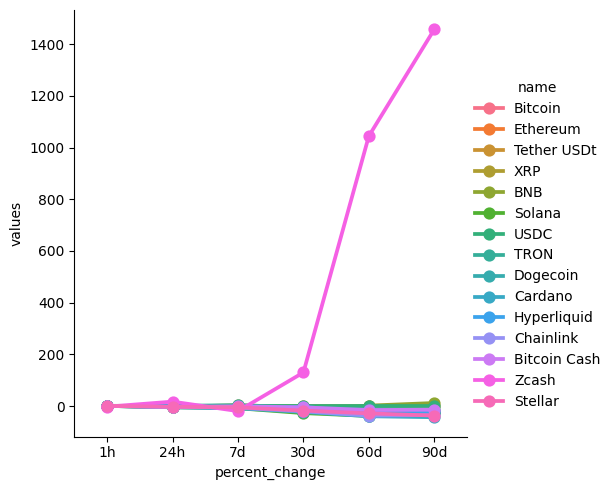

In [53]:
sns.catplot(x='percent_change', y='values', hue='name', data=df7, kind='point')

In [56]:
# Now to do something much simpler
# we are going to create a dataframe with the columns we want

df10 = df[['name','quote.USD.price','timestamp','Timestamp']]
df10 = df10.query("name == 'Bitcoin'")
df10

,name,quote.USD.price,timestamp,Timestamp
0,Bitcoin,96957.07794,2025-11-14 22:22:30.358940,NaT
15,Bitcoin,97147.53723,NaT,2025-11-14 22:22:38.537338
30,Bitcoin,97176.21592,NaT,2025-11-14 22:23:39.471951
45,Bitcoin,97162.74166,NaT,2025-11-14 22:24:40.449990
60,Bitcoin,97163.71225,NaT,2025-11-14 22:25:41.578493
75,Bitcoin,97165.21142,NaT,2025-11-14 22:26:42.118119
90,Bitcoin,97090.62128,NaT,2025-11-14 22:28:56.470515
105,Bitcoin,97042.62609,NaT,2025-11-14 22:30:09.502646
120,Bitcoin,97009.90580,NaT,2025-11-14 22:31:10.216394
135,Bitcoin,97010.56909,NaT,2025-11-14 22:32:10.766486


<Axes: xlabel='Timestamp', ylabel='quote.USD.price'>

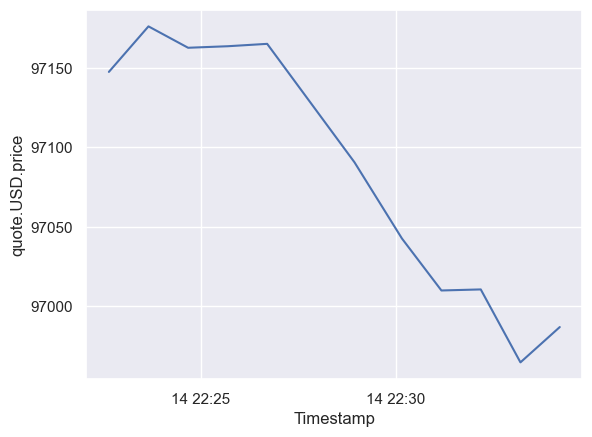

In [59]:
sns.set_theme(style="darkgrid")

sns.lineplot(x='Timestamp', y='quote.USD.price', data = df10)